# Regularized XGBoost Model — Load & Evaluate

Loads the anti-overfitting model saved at `data/pipeline_output_regularized/`.

Key differences from the tuned model:
- `max_depth=2` (was 6) — much shallower trees
- `min_child_weight=20` (was 5) — strong leaf regularization
- `reg_lambda=5` — L2 weight regularization (new)
- `subsample=0.6`, `colsample_bytree=0.6` — aggressive subsampling

Result: Train RMSE dropped from **0.0005 → 0.3934**, confirming overfitting is controlled.

## 1. Import Libraries

In [1]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import mean_squared_error

print("Libraries loaded.")

Libraries loaded.


## 2. Define Paths

In [2]:
BASE_DIR    = Path("..").resolve()
OUTPUT_DIR  = BASE_DIR / "data" / "pipeline_output_regularized"
TUNED_DIR   = BASE_DIR / "data" / "pipeline_output_tuned"

MODEL_PATH      = OUTPUT_DIR / "xgb_regularized_model.joblib"
SUMMARY_PATH    = OUTPUT_DIR / "xgb_final_summary.json"
PREDICTIONS_CSV = OUTPUT_DIR / "xgb_test_predictions.csv"
GRID_CSV        = OUTPUT_DIR / "xgb_grid_search.csv"

# Also load tuned model predictions for comparison
TUNED_PREDS_CSV = TUNED_DIR / "xgb_test_predictions.csv"
TUNED_SUMMARY   = TUNED_DIR / "xgb_final_summary.json"

for p in [MODEL_PATH, SUMMARY_PATH, PREDICTIONS_CSV]:
    print(f"  {'✓' if p.exists() else '✗ MISSING'}  {p.name}")

  ✓  xgb_regularized_model.joblib
  ✓  xgb_final_summary.json
  ✓  xgb_test_predictions.csv


## 3. Load the Model

In [3]:
model = joblib.load(MODEL_PATH)
print(f"Model loaded: {type(model).__name__}")

Model loaded: XGBRegressor


## 4. Verify — Summary & Hyperparameters

In [4]:
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

print("=" * 58)
print("REGULARIZED MODEL SUMMARY")
print("=" * 58)
print(f"  Model type   : {summary['model']}")
print(f"  Features (K) : {summary['best_k']}")
print()
print("  Best hyperparameters:")
for k, v in summary["best_params"].items():
    print(f"    {k:<22s}: {v}")
print()
print("  Performance across splits:")
print(f"    {'Split':<10s} {'RMSE':>8s} {'ACC':>8s}")
print(f"    {'-'*10} {'-'*8} {'-'*8}")
print(f"    {'Train':<10s} {summary['train_rmse']:>8.4f} {summary['train_acc']:>8.4f}")
print(f"    {'Val':<10s} {summary['val_rmse']:>8.4f}  {summary['val_acc']:>7.4f}")
print(f"    {'Test':<10s} {summary['test_rmse']:>8.4f}  {summary['test_acc']:>7.4f}")
print("=" * 58)
print(f"\n  Train→Test RMSE gap: {summary['test_rmse'] - summary['train_rmse']:+.4f}"
      f"  (was +0.8900 before regularization)")

REGULARIZED MODEL SUMMARY
  Model type   : XGBRegressor (regularized)
  Features (K) : 18

  Best hyperparameters:
    max_depth             : 2
    n_estimators          : 300
    learning_rate         : 0.05
    subsample             : 0.6
    colsample_bytree      : 0.6
    min_child_weight      : 20
    reg_alpha             : 0
    reg_lambda            : 5

  Performance across splits:
    Split          RMSE      ACC
    ---------- -------- --------
    Train        0.3934   0.9139
    Val          0.6000   0.5732
    Test         0.9077   0.8163

  Train→Test RMSE gap: +0.5143  (was +0.8900 before regularization)


## 5. Test Predictions — Actual vs Predicted

Test RMSE: 0.9077  |  Test ACC: 0.8163


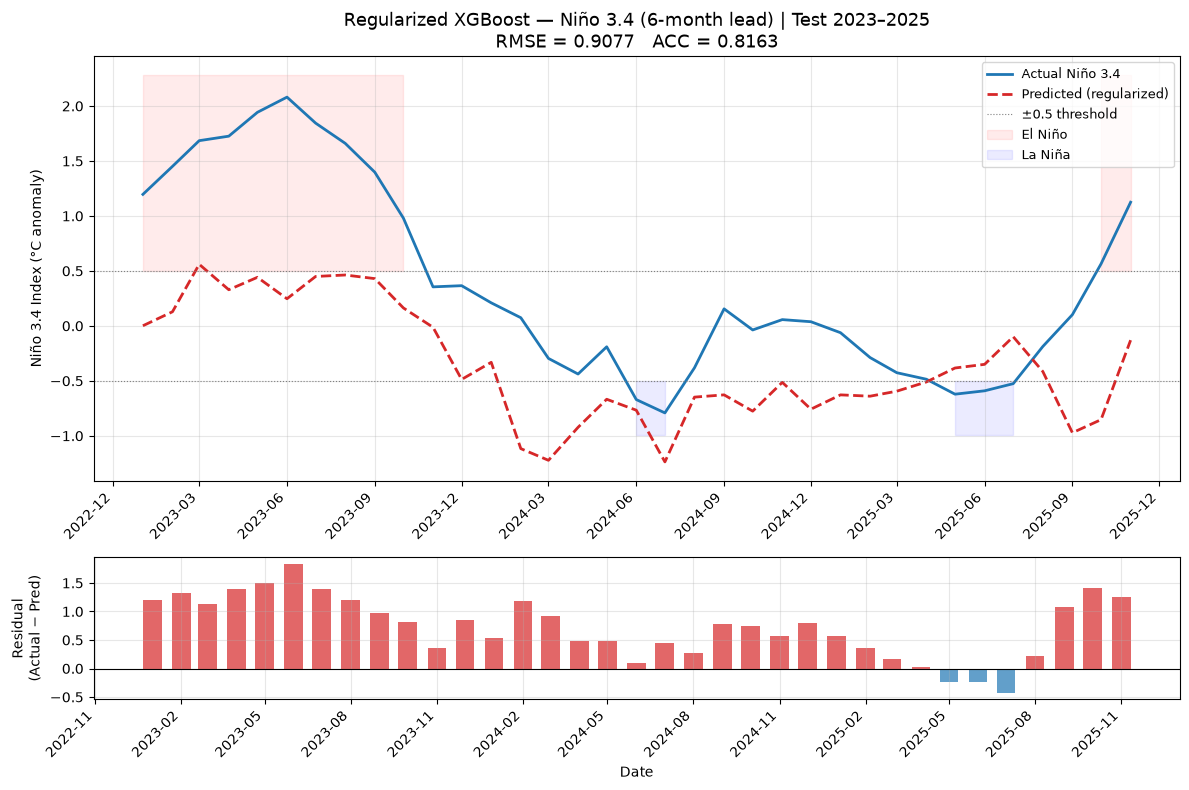

In [5]:
preds = pd.read_csv(PREDICTIONS_CSV, parse_dates=["window_end"])
actual    = preds["actual_nino34"].values
predicted = preds["predicted_nino34"].values
dates     = preds["window_end"]

rmse = np.sqrt(mean_squared_error(actual, predicted))
acc  = np.corrcoef(actual, predicted)[0, 1]
print(f"Test RMSE: {rmse:.4f}  |  Test ACC: {acc:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(dates, actual,    label="Actual Niño 3.4",        color="#1f77b4", linewidth=2)
ax.plot(dates, predicted, label="Predicted (regularized)", color="#d62728",
        linewidth=2, linestyle="--")
ax.axhline( 0.5, color="gray", linewidth=0.8, linestyle=":", label="±0.5 threshold")
ax.axhline(-0.5, color="gray", linewidth=0.8, linestyle=":")
ax.fill_between(dates, 0.5, actual.max() + 0.2,
                where=(actual >= 0.5), alpha=0.08, color="red",  label="El Niño")
ax.fill_between(dates, actual.min() - 0.2, -0.5,
                where=(actual <= -0.5), alpha=0.08, color="blue", label="La Niña")
ax.set_title(f"Regularized XGBoost — Niño 3.4 (6-month lead) | Test 2023–2025\n"
             f"RMSE = {rmse:.4f}   ACC = {acc:.4f}", fontsize=13)
ax.set_ylabel("Niño 3.4 Index (°C anomaly)")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(True, alpha=0.3)

residuals = actual - predicted
ax2 = axes[1]
ax2.bar(dates, residuals,
        color=["#d62728" if r > 0 else "#1f77b4" for r in residuals],
        width=20, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Residual\n(Actual − Pred)")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_predictions_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Overfitting Check — Train / Val / Test Side-by-Side

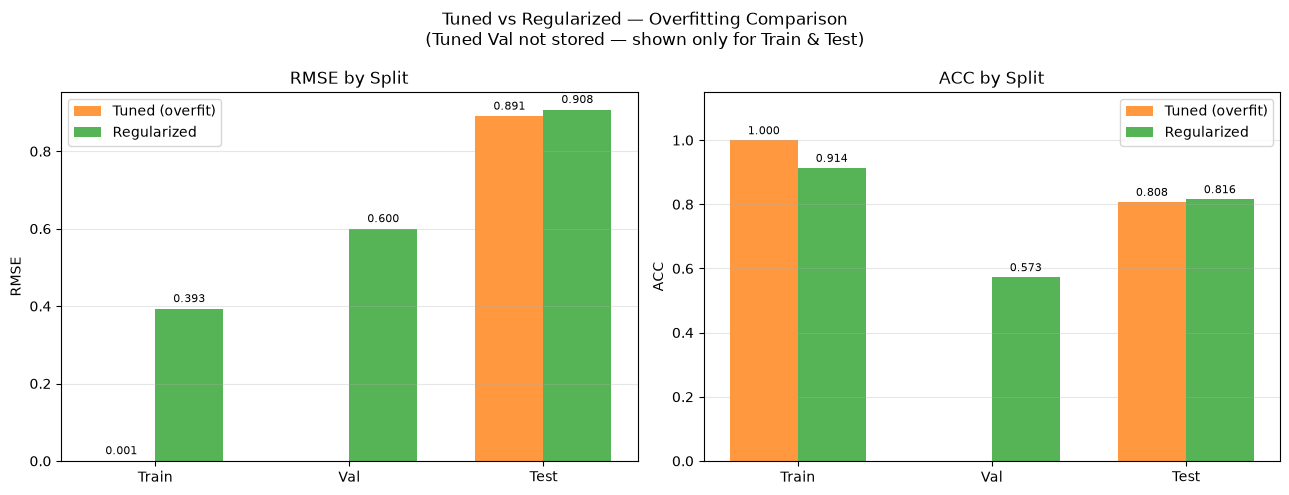

In [7]:
splits_data = {
    "Train": {"rmse": summary["train_rmse"], "acc": summary["train_acc"]},
    "Val":   {"rmse": summary["val_rmse"],   "acc": summary["val_acc"]},
    "Test":  {"rmse": summary["test_rmse"],  "acc": summary["test_acc"]},
}

# Compare with tuned model (beta=1.0)
# Tuned summary only stored test metrics; train RMSE was 0.0005, train ACC 1.0
with open(TUNED_SUMMARY) as f:
    tuned_s = json.load(f)

labels = list(splits_data.keys())
reg_rmse = [splits_data[s]["rmse"] for s in labels]
reg_acc  = [splits_data[s]["acc"]  for s in labels]

tuned_rmse = [0.0005, None,                    tuned_s["test_rmse"]]
tuned_acc  = [1.0000, None,                    tuned_s["test_acc"]]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# RMSE bars — skip None (val not stored for tuned)
for i, (val, lbl) in enumerate(zip(tuned_rmse, labels)):
    if val is not None:
        b = ax1.bar(i - width/2, val, width, color="#ff7f0e", alpha=0.8,
                    label="Tuned (overfit)" if i == 0 else "")
        ax1.text(b[0].get_x() + b[0].get_width()/2,
                 b[0].get_height() + 0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=8)

for i, (val, lbl) in enumerate(zip(reg_rmse, labels)):
    b = ax1.bar(i + width/2, val, width, color="#2ca02c", alpha=0.8,
                label="Regularized" if i == 0 else "")
    ax1.text(b[0].get_x() + b[0].get_width()/2,
             b[0].get_height() + 0.01, f"{val:.3f}",
             ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("RMSE"); ax1.set_title("RMSE by Split")
ax1.legend(); ax1.grid(True, axis="y", alpha=0.3)

# ACC bars
for i, val in enumerate(tuned_acc):
    if val is not None:
        b = ax2.bar(i - width/2, val, width, color="#ff7f0e", alpha=0.8,
                    label="Tuned (overfit)" if i == 0 else "")
        ax2.text(b[0].get_x() + b[0].get_width()/2,
                 b[0].get_height() + 0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=8)

for i, val in enumerate(reg_acc):
    b = ax2.bar(i + width/2, val, width, color="#2ca02c", alpha=0.8,
                label="Regularized" if i == 0 else "")
    ax2.text(b[0].get_x() + b[0].get_width()/2,
             b[0].get_height() + 0.01, f"{val:.3f}",
             ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel("ACC"); ax2.set_title("ACC by Split")
ax2.set_ylim(0, 1.15); ax2.legend(); ax2.grid(True, axis="y", alpha=0.3)

plt.suptitle("Tuned vs Regularized — Overfitting Comparison\n"
             "(Tuned Val not stored — shown only for Train & Test)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overfitting_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Feature Importances

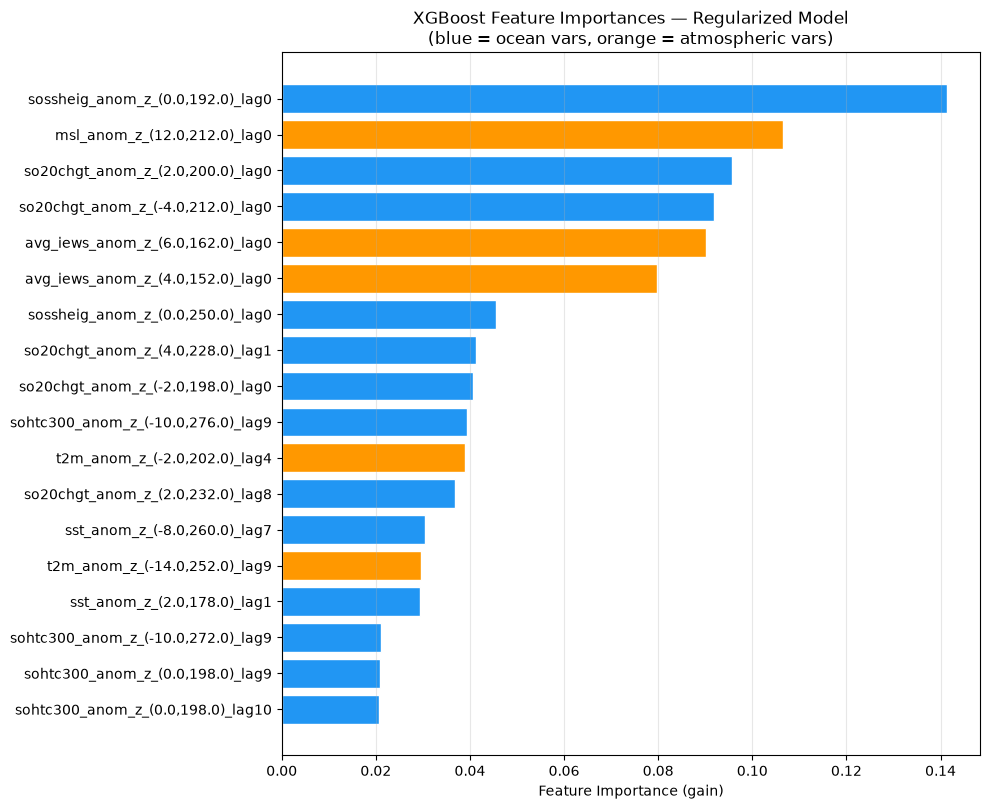


Top 5 most important features:
  0.1413  sossheig_anom_z_(0.0,192.0)_lag0
  0.1065  msl_anom_z_(12.0,212.0)_lag0
  0.0958  so20chgt_anom_z_(2.0,200.0)_lag0
  0.0919  so20chgt_anom_z_(-4.0,212.0)_lag0
  0.0901  avg_iews_anom_z_(6.0,162.0)_lag0


In [8]:
feature_names = summary["selected_features"]
importances   = model.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 0.4 * len(fi) + 1))
colors = ["#2196F3" if any(v in f for v in ["sst_anom", "sohtc", "so20", "soss"])
          else "#FF9800" for f in fi.index]
ax.barh(fi.index, fi.values, color=colors, edgecolor="white")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importances — Regularized Model\n"
             "(blue = ocean vars, orange = atmospheric vars)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importances_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
for name, val in fi.sort_values(ascending=False).head(5).items():
    print(f"  {val:.4f}  {name}")